# Test Experimental Summary Results

Notebook này test file `summarize_experiments.py`, kiểm tra output JSON/Markdown, validate key metrics, và vẽ nhanh kết quả training/evaluation.

Chạy từ root repo `MAP-RAG-Gym`.

In [1]:
from pathlib import Path
import json
import subprocess
import sys

import pandas as pd
import matplotlib.pyplot as plt

ROOT = Path.cwd()
OUT = ROOT / 'outputs'
SUMMARY_JSON = OUT / 'experimental_setup_and_train_results_summary.json'
SUMMARY_MD = OUT / 'experimental_setup_and_train_results_summary.md'

print('ROOT =', ROOT)
print('Python =', sys.executable)
print('Summary script exists:', (ROOT / 'summarize_experiments.py').exists())

ROOT = g:\MAP-RAG-Gym
Python = g:\MAP-RAG-Gym\.venv\Scripts\python.exe
Summary script exists: True


## 1. Run summary script

Cell này chạy script với `--no-full-log` để log không quá dài trong notebook. Nếu muốn xem full JSON log, bỏ flag này.

In [2]:
cmd = [sys.executable, 'summarize_experiments.py', '--no-full-log']
result = subprocess.run(cmd, cwd=ROOT, capture_output=True, text=True)
print('Return code:', result.returncode)
print('--- STDOUT ---')
print(result.stdout)
print('--- STDERR ---')
print(result.stderr)
assert result.returncode == 0, 'summarize_experiments.py failed'
assert SUMMARY_JSON.exists(), f'Missing {SUMMARY_JSON}'
assert SUMMARY_MD.exists(), f'Missing {SUMMARY_MD}'

Return code: 0
--- STDOUT ---
Wrote Markdown summary: outputs/experimental_setup_and_train_results_summary.md
Wrote JSON summary: outputs/experimental_setup_and_train_results_summary.json

--- STDERR ---
[INFO] start summary generation
[INFO] output_dir=outputs
[INFO] markdown_out=outputs/experimental_setup_and_train_results_summary.md
[INFO] json_out=outputs/experimental_setup_and_train_results_summary.json
[INFO] checking source files
[INFO] source full_system_rl_package         FOUND outputs/full_system_rl_package.json
[INFO] source macro_budget_metrics           FOUND outputs/metrics/metrics_macro_budget_summary.csv
[INFO] source micro_critic_metrics           FOUND outputs/metrics/metrics_micro_critic_summary.csv
[INFO] source cv_ensemble_report             FOUND outputs/cv_ensemble_report.json
[INFO] source selective_critic_verification  FOUND outputs/selective_critic_verification.json
[INFO] source regate_report                  FOUND outputs/regate_report.json
[INFO] building s

## 2. Load and inspect summary JSON

In [3]:
summary = json.loads(SUMMARY_JSON.read_text(encoding='utf-8'))
print('Top-level keys:')
for key in summary.keys():
    print('-', key)

print('\nGenerated at:', summary.get('generated_at_utc'))
print('Output dir:', summary.get('output_dir'))

Top-level keys:
- generated_at_utc
- output_dir
- source_files
- experimental_setup
- macro_budget_results
- micro_critic_results
- bandit_result
- selective_critic_result
- rl_status

Generated at: 2026-06-10T14:51:34+00:00
Output dir: outputs


## 3. Validate expected fields

Các assert này giúp test nhanh report có đủ thông số chính không.

In [4]:
required_keys = [
    'experimental_setup',
    'macro_budget_results',
    'micro_critic_results',
    'bandit_result',
    'selective_critic_result',
    'rl_status',
]
for key in required_keys:
    assert key in summary, f'Missing key: {key}'

assert len(summary['macro_budget_results']) >= 3, 'Need at least 3 budget rows'
assert len(summary['micro_critic_results']) >= 1, 'Need critic rows'
assert summary['bandit_result'].get('avg_regret') is not None, 'Missing bandit regret'
assert summary['rl_status'].get('online_rl_ready') is not None, 'Missing online RL status'

print('All validation checks passed ✅')

All validation checks passed ✅


## 4. Macro budget results table

In [5]:
macro_df = pd.DataFrame(summary['macro_budget_results'])
numeric_cols = ['num_runs', 'avg_utility', 'avg_em', 'avg_f1_proxy', 'avg_tokens', 'avg_latency_ms', 'zero_utility_rate']
for col in numeric_cols:
    if col in macro_df.columns:
        macro_df[col] = pd.to_numeric(macro_df[col], errors='coerce')
macro_df

,budget_mode,method,num_runs,avg_utility,avg_em,avg_f1_proxy,avg_tokens,avg_latency_ms,workflow_distribution,zero_utility_rate
0,low,gated_bandit_router,90,0.2776,0.2222,0.2720,104.46,761.99,"{'W1': 25, 'W3': 65}",0.6000
1,medium,bandit_router,90,0.3613,0.2444,0.3011,116.40,907.93,"{'W1': 36, 'W3': 43, 'W2': 6, 'W6': 5}",0.4444
2,high,bandit_router,90,0.4375,0.2778,0.3220,176.53,1151.62,"{'W3': 53, 'W2': 37}",0.0000


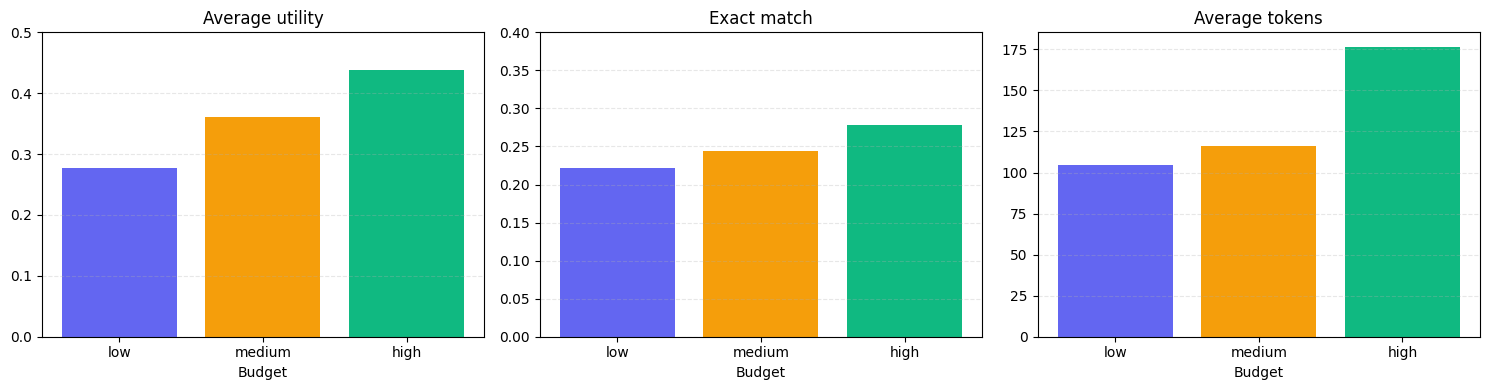

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
order = ['low', 'medium', 'high']
plot_df = macro_df.set_index('budget_mode').reindex(order).reset_index()

axes[0].bar(plot_df['budget_mode'], plot_df['avg_utility'], color=['#6366f1', '#f59e0b', '#10b981'])
axes[0].set_title('Average utility')
axes[0].set_ylim(0, max(0.5, plot_df['avg_utility'].max() + 0.05))

axes[1].bar(plot_df['budget_mode'], plot_df['avg_em'], color=['#6366f1', '#f59e0b', '#10b981'])
axes[1].set_title('Exact match')
axes[1].set_ylim(0, max(0.4, plot_df['avg_em'].max() + 0.05))

axes[2].bar(plot_df['budget_mode'], plot_df['avg_tokens'], color=['#6366f1', '#f59e0b', '#10b981'])
axes[2].set_title('Average tokens')

for ax in axes:
    ax.grid(axis='y', linestyle='--', alpha=0.3)
    ax.set_xlabel('Budget')

plt.tight_layout()
plt.show()

## 5. Micro critic results table + checks

In [7]:
critic_df = pd.DataFrame(summary['micro_critic_results'])
critic_numeric = ['train_examples', 'eval_examples', 'eval_mae', 'eval_rmse', 'eval_pearson', 'eval_spearman']
for col in critic_numeric:
    if col in critic_df.columns:
        critic_df[col] = pd.to_numeric(critic_df[col], errors='coerce')
critic_df

,module,train_examples,eval_examples,train_budget_low,train_budget_medium,train_budget_high,eval_mae,eval_rmse,eval_pearson,eval_spearman,ready_as_offline_reward_model
0,AG,4283,756,0,4283,0,0.2203,0.2950,0.2987,0.2112,False
1,QR,1071,189,0,1071,0,0.0955,0.1202,0.7050,0.6745,True


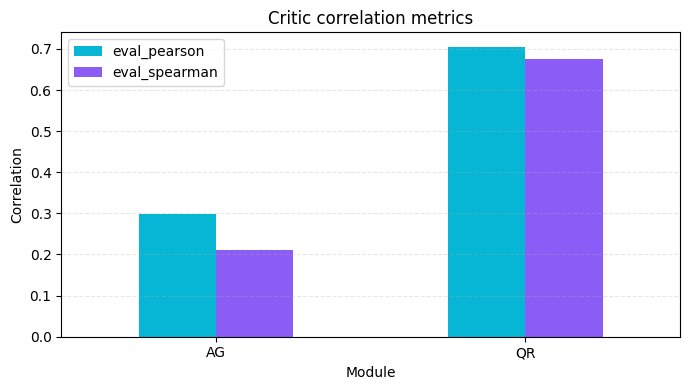

In [8]:
fig, ax = plt.subplots(figsize=(7, 4))
critic_df.plot(x='module', y=['eval_pearson', 'eval_spearman'], kind='bar', ax=ax, color=['#06b6d4', '#8b5cf6'])
ax.set_title('Critic correlation metrics')
ax.set_ylabel('Correlation')
ax.set_xlabel('Module')
ax.grid(axis='y', linestyle='--', alpha=0.3)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

## 6. Bandit + selective critic + RL gate checks

In [9]:
bandit = summary['bandit_result']
selective = summary['selective_critic_result']
rl = summary['rl_status']

checks = pd.DataFrame([
    {'component': 'High-budget bandit', 'metric': 'avg_regret', 'value': bandit.get('avg_regret'), 'target': '<= 0.04'},
    {'component': 'High-budget bandit', 'metric': 'exact_best_rate', 'value': bandit.get('exact_best_rate'), 'target': '>= 0.70'},
    {'component': 'Selective critic', 'metric': 'online_token_multiplier', 'value': selective.get('online_token_multiplier'), 'target': '<= 1.25'},
    {'component': 'Selective critic', 'metric': 'online_utility_gap', 'value': selective.get('online_utility_gap'), 'target': '>= -0.001'},
    {'component': 'RL gate', 'metric': 'online_rl_ready', 'value': rl.get('online_rl_ready'), 'target': 'True'},
])
checks

,component,metric,value,target
0,High-budget bandit,avg_regret,0.0193,<= 0.04
1,High-budget bandit,exact_best_rate,0.8333,>= 0.70
2,Selective critic,online_token_multiplier,1.0,<= 1.25
3,Selective critic,online_utility_gap,0.0,>= -0.001
4,RL gate,online_rl_ready,True,True


In [10]:
assert float(bandit['avg_regret']) <= 0.04, 'Bandit regret gate failed'
assert float(bandit['exact_best_rate']) >= 0.70, 'Bandit best-rate gate failed'
assert float(selective.get('online_token_multiplier', 999)) <= 1.25, 'Critic token gate failed'
assert float(selective.get('online_utility_gap', -999)) >= -0.001, 'Critic utility gate failed'
assert bool(rl.get('online_rl_ready')) is True, 'Online RL gate failed'
print('Bandit / critic / online RL gates passed ✅')

Bandit / critic / online RL gates passed ✅


## 7. Preview generated Markdown report

In [11]:
md_text = SUMMARY_MD.read_text(encoding='utf-8')
print(md_text[:4000])
print('\n--- preview truncated ---')

# Experimental Setup and Training Results Summary

Generated at UTC: `2026-06-10T14:51:34+00:00`
Output directory: `outputs`

## 1. Experimental Setup

| Item | Value |
| --- | --- |
| Dataset/package name | full_system_rl |
| Split/stage | gate |
| Effective questions | 270 |
| Policy bundle | outputs/final_budget_policy_bundle.json |
| Final evaluation | outputs/final_budget_policy_test_eval.json |
| Final report | outputs/final_project_report.json |

### Counterfactual Rollout Coverage

| Budget | Questions | Runs | Workflow counts | Workflow avg utility | Has counterfactuals |
| --- | --- | --- | --- | --- | --- |
| high | 420 | 840 | {'W2': 420, 'W3': 420} | {'W2': 0.3666, 'W3': 0.3924} | Yes |
| low | 420 | 1680 | {'W1': 420, 'W2': 420, 'W3': 420, 'W6': 420} | {'W1': 0.2212, 'W2': 0.3056, 'W3': 0.3433, 'W6': 0.2547} | Yes |
| medium | 420 | 1680 | {'W1': 420, 'W2': 420, 'W3': 420, 'W6': 420} | {'W1': 0.2212, 'W2': 0.3056, 'W3': 0.3433, 'W6': 0.2547} | Yes |

## 2. Macro Budget Po

## 8. Live QA Demo Samples for LLM

Phần này giống tab `Live Demo` trong `streamlit_app.py`: lấy vài câu QA thật, cho router chọn workflow theo budget, rồi chạy `MAPRAGGym` để test LLM/pipeline.

Mặc định dùng `dummy` provider để chạy nhanh. Muốn test LLM thật thì đổi sang `ollama` hoặc `gemini` trong cell config bên dưới.


In [13]:
import sys, json, time
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
OUT = ROOT / 'outputs'
sys.path.insert(0, str(ROOT / 'src'))

from map_rag_gym.core.pipeline import MAPRAGGym

# ===== Live demo config =====
LIVE_PROVIDER = 'ollama'       # 'dummy' | 'ollama' | 'gemini'
LIVE_MODEL = 'llama3.2'     # ollama: 'llama3.2' | gemini: 'gemini-2.0-flash'
LIVE_DATASET = 'sample'       # 'sample' | 'hotpotqa' | 'hotpotqa_large' | '2wikimultihopqa'
LIVE_BUDGETS = ['low', 'medium', 'high']

print('Provider:', LIVE_PROVIDER)
print('Model:', LIVE_MODEL)
print('Dataset:', LIVE_DATASET)
print('Budgets:', LIVE_BUDGETS)


Provider: ollama
Model: llama3.2
Dataset: sample
Budgets: ['low', 'medium', 'high']


### 8.1 Load vài câu QA để test

Ưu tiên `data/<dataset>/splits/test.json`; nếu không có thì dùng `data/<dataset>/qa.json`.


In [14]:
def load_qa_samples(dataset='sample', n=5):
    candidates = [
        ROOT / 'data' / dataset / 'splits' / 'test.json',
        ROOT / 'data' / dataset / 'qa.json',
    ]
    qa_path = next((p for p in candidates if p.exists()), None)
    if qa_path is None:
        raise FileNotFoundError(f'No QA file found for dataset={dataset}')

    data = json.loads(qa_path.read_text(encoding='utf-8'))
    rows = []
    for item in data[:n]:
        rows.append({
            'id': item.get('id', ''),
            'question': item.get('question', ''),
            'gold_answer': item.get('answer', item.get('gold_answer', '')),
            'type': (item.get('metadata', {}) or {}).get('type', 'multi-hop'),
            'source_file': str(qa_path.relative_to(ROOT)).replace('\\', '/'),
        })
    return pd.DataFrame(rows)

qa_samples = load_qa_samples(LIVE_DATASET, n=5)
qa_samples


,id,question,gold_answer,type,source_file
0,,Who wrote Pride and Prejudice?,Jane Austen,multi-hop,data/sample/qa.json
1,,Which novel by the author of Pride and Prejudi...,Persuasion,multi-hop,data/sample/qa.json
2,,Compare California and Japan in terms of GDP.,California has a GDP larger than Japan in this...,multi-hop,data/sample/qa.json


### 8.2 Router helper giống Streamlit Live Demo

Load `final_budget_policy_bundle_rl_ready.json` / `final_budget_policy_bundle.json`, dùng bandit nếu có; thiếu model thì fallback workflow `W3`.


In [15]:
def select_workflow_like_streamlit(question, budget='high', dataset='sample'):
    bundle_path = OUT / 'final_budget_policy_bundle_rl_ready.json'
    if not bundle_path.exists():
        bundle_path = OUT / 'final_budget_policy_bundle.json'

    selected_workflow = 'W3'
    planner_reason = 'fallback:W3'
    router_info = {'mode': 'fallback', 'workflow': selected_workflow}

    if not bundle_path.exists():
        router_info['reason'] = 'No policy bundle found'
        return selected_workflow, planner_reason, router_info

    bundle = json.loads(bundle_path.read_text(encoding='utf-8'))
    bp = bundle.get('budget_policies', {}).get(budget, {})
    method = bp.get('recommended_method', 'fixed_W3')
    rs = bp.get('router_settings', {})
    bandit_model_path = rs.get('bandit_router_model')

    if not bandit_model_path or not (ROOT / bandit_model_path).exists():
        if method.startswith('fixed_'):
            selected_workflow = method.replace('fixed_', '')
            planner_reason = f'static_policy:{selected_workflow}'
            router_info = {'mode': 'static_policy', 'workflow': selected_workflow, 'method': method}
        else:
            router_info = {'mode': 'fallback', 'reason': 'No bandit model found', 'workflow': selected_workflow, 'method': method}
        return selected_workflow, planner_reason, router_info

    from map_rag_gym.router.bandit import BanditRouter
    from map_rag_gym.retrieval.bm25 import LocalBM25Retriever

    corpus_path = str(ROOT / 'data' / dataset / 'corpus.json')
    bandit = BanditRouter()
    bandit.load(str(ROOT / bandit_model_path))
    bandit.attach_probe_retriever(LocalBM25Retriever(corpus_path))

    if 'gated' in method:
        wf, conf, scores, gate_meta = bandit.predict_with_gate(
            question, budget_mode=budget,
            baseline_workflow=rs.get('bandit_gate_baseline_workflow', 'W3'),
            minimum_advantage=rs.get('bandit_gate_min_advantage', 0.0),
            minimum_confidence=rs.get('bandit_gate_min_confidence', 0.0),
            allowed_switch_workflows=rs.get('bandit_gate_allowed_workflows', []),
        )
        return wf, f'gated_bandit:{conf:.4f}', {
            'mode': 'gated_bandit_router', 'workflow': wf,
            'confidence': round(float(conf), 4),
            'scores': {k: round(float(v), 4) for k, v in scores.items()},
            'gate': gate_meta,
        }

    wf, conf, scores = bandit.predict_with_scores(question, budget_mode=budget)
    return wf, f'bandit:{conf:.4f}', {
        'mode': 'bandit_router', 'workflow': wf,
        'confidence': round(float(conf), 4),
        'scores': {k: round(float(v), 4) for k, v in scores.items()},
    }

router_preview = []
for _, row in qa_samples.head(3).iterrows():
    for budget in LIVE_BUDGETS:
        wf, reason, info = select_workflow_like_streamlit(row['question'], budget=budget, dataset=LIVE_DATASET)
        router_preview.append({
            'id': row['id'], 'budget': budget, 'workflow': wf, 'reason': reason,
            'mode': info.get('mode'), 'confidence': info.get('confidence'), 'scores': info.get('scores'),
        })

pd.DataFrame(router_preview)


,id,budget,workflow,reason,mode,confidence,scores
0,,low,W3,fallback:W3,fallback,None,None
1,,medium,W3,fallback:W3,fallback,None,None
2,,high,W3,fallback:W3,fallback,None,None
3,,low,W3,fallback:W3,fallback,None,None
4,,medium,W3,fallback:W3,fallback,None,None
5,,high,W3,fallback:W3,fallback,None,None
6,,low,W3,fallback:W3,fallback,None,None
7,,medium,W3,fallback:W3,fallback,None,None
8,,high,W3,fallback:W3,fallback,None,None


### 8.3 Run pipeline cho vài câu QA

Mặc định chạy **2 câu đầu × 3 budgets**. Nếu đổi sang `ollama/gemini`, cell này sẽ gọi LLM thật và lâu hơn.


In [16]:
def run_live_qa(question, gold_answer, budget='high', dataset='sample', provider='dummy', model='dummy-free'):
    corpus_path = ROOT / 'data' / dataset / 'corpus.json'
    if not corpus_path.exists():
        raise FileNotFoundError(f'Missing corpus: {corpus_path}')

    workflow, planner_reason, router_info = select_workflow_like_streamlit(question, budget=budget, dataset=dataset)
    pipe = MAPRAGGym(str(corpus_path), llm_provider=provider, llm_model=model)

    t0 = time.time()
    result = pipe.run(question, gold_answer, workflow, planner_reason=planner_reason, budget_mode=budget)
    elapsed = time.time() - t0

    return {
        'budget': budget,
        'workflow': workflow,
        'router_mode': router_info.get('mode'),
        'router_confidence': router_info.get('confidence'),
        'router_scores': router_info.get('scores'),
        'question': question,
        'gold_answer': gold_answer,
        'final_answer': result.final_answer,
        'utility': result.final_scores.get('utility_total', 0),
        'exact_match': result.final_scores.get('exact_match', 0),
        'f1': result.final_scores.get('f1', 0),
        'tokens': result.total_cost.get('tokens', 0),
        'retrieval_calls': result.total_cost.get('retrieval_calls', 0),
        'latency_ms': result.total_cost.get('latency_ms', 0),
        'elapsed_s': elapsed,
        'num_steps': len(result.steps),
        'steps': [
            {
                'step_id': s.step_id, 'module': s.module,
                'scores': s.scores, 'cost': s.cost, 'notes': s.notes,
                'input_data': s.input_data, 'output_data': s.output_data,
            }
            for s in result.steps
        ],
    }

live_results = []
for _, row in qa_samples.head(2).iterrows():
    for budget in LIVE_BUDGETS:
        print(f"Running id={row['id']} budget={budget} provider={LIVE_PROVIDER}/{LIVE_MODEL}")
        live_results.append(run_live_qa(
            row['question'], row['gold_answer'], budget=budget,
            dataset=LIVE_DATASET, provider=LIVE_PROVIDER, model=LIVE_MODEL,
        ))

live_df = pd.DataFrame([{k: v for k, v in r.items() if k != 'steps'} for r in live_results])
live_df


Running id= budget=low provider=ollama/llama3.2
Running id= budget=medium provider=ollama/llama3.2
Running id= budget=high provider=ollama/llama3.2
Running id= budget=low provider=ollama/llama3.2
Running id= budget=medium provider=ollama/llama3.2
Running id= budget=high provider=ollama/llama3.2


,budget,workflow,router_mode,router_confidence,router_scores,question,gold_answer,final_answer,utility,exact_match,f1,tokens,retrieval_calls,latency_ms,elapsed_s,num_steps
0,low,W3,fallback,None,None,Who wrote Pride and Prejudice?,Jane Austen,Jane Austen,1.0245,0,0,147.0,1.0,8108.55,8.109052,3
1,medium,W3,fallback,None,None,Who wrote Pride and Prejudice?,Jane Austen,Jane Austen,1.2086,0,0,147.0,1.0,3506.50,3.506499,3
2,high,W3,fallback,None,None,Who wrote Pride and Prejudice?,Jane Austen,Jane Austen,1.3016,0,0,147.0,1.0,3644.98,3.644988,3
3,low,W3,fallback,None,None,Which novel by the author of Pride and Prejudi...,Persuasion,Persuasion,1.0783,0,0,156.0,1.0,3746.94,3.746944,3
4,medium,W3,fallback,None,None,Which novel by the author of Pride and Prejudi...,Persuasion,Persuasion,1.2109,0,0,156.0,1.0,3597.48,3.597979,3
5,high,W3,fallback,None,None,Which novel by the author of Pride and Prejudi...,Persuasion,Persuasion,1.3058,0,0,156.0,1.0,3500.91,3.500909,3


### 8.4 Inspect chi tiết pipeline steps

In input/output/score/cost từng module cho 1 run, giống expander trong Streamlit.


In [18]:
run_idx = 0
run = live_results[run_idx]

print('Question:', run['question'])
print('Gold:', run['gold_answer'])
print('Answer:', run['final_answer'])
print('Budget:', run['budget'], '| Workflow:', run['workflow'], '| Router:', run['router_mode'])
print('Utility:', run['utility'], '| EM:', run['exact_match'], '| F1:', run['f1'])
print('Tokens:', run['tokens'], '| Retrieval calls:', run['retrieval_calls'], '| Latency ms:', run['latency_ms'])

for step in run['steps']:
    print('' + '=' * 90)
    print(f"Step {step['step_id']} | module={step['module']}")
    print('Scores:', step['scores'])
    print('Cost:', step['cost'])
    print('Notes:', step['notes'])
    print('Input:', json.dumps(step['input_data'], indent=2, ensure_ascii=False)[:2000])
    print('Output:', json.dumps(step['output_data'], indent=2, ensure_ascii=False)[:2000])


Question: Who wrote Pride and Prejudice?
Gold: Jane Austen
Answer: Jane Austen
Budget: low | Workflow: W3 | Router: fallback
Utility: 1.0245 | EM: 0 | F1: 0
Tokens: 147.0 | Retrieval calls: 1.0 | Latency ms: 8108.55
Step 1 | module=RA
Scores: {'retrieval_utility': 0.7222}
Cost: {'retrieval_calls': 1, 'latency_ms': 0.0}
Notes: 
Input: {
  "query": "Who wrote Pride and Prejudice?",
  "top_k": 4,
  "retriever_type": "bm25"
}
Output: {
  "docs": [
    {
      "doc_id": "d1",
      "title": "Pride and Prejudice",
      "score": 1.0821154361465637
    },
    {
      "doc_id": "d2",
      "title": "Jane Austen",
      "score": 0.9471188569837249
    },
    {
      "doc_id": "d7",
      "title": "Wikipedia style note",
      "score": 0.2615489525095403
    },
    {
      "doc_id": "d3",
      "title": "Persuasion",
      "score": 0.0
    }
  ],
  "retriever_type": "bm25"
}
Step 2 | module=DS
Scores: {'selection_precision': 0.75}
Cost: {'latency_ms': 0.0}
Notes: 
Input: {
  "num_docs": 4,
  "ke

### 8.5 Custom question

Nhập câu hỏi riêng tại đây để test nhanh.


In [19]:
custom_question = 'Were Scott Derrickson and Ed Wood of the same nationality?'
custom_gold = 'Yes'
custom_budget = 'high'

custom_result = run_live_qa(
    custom_question, custom_gold,
    budget=custom_budget,
    dataset=LIVE_DATASET,
    provider=LIVE_PROVIDER,
    model=LIVE_MODEL,
)

print('Answer:', custom_result['final_answer'])
print('Utility:', custom_result['utility'], '| EM:', custom_result['exact_match'], '| F1:', custom_result['f1'])
print('Workflow:', custom_result['workflow'], '| Router:', custom_result['router_mode'], '| Budget:', custom_result['budget'])
print('Tokens:', custom_result['tokens'], '| Steps:', custom_result['num_steps'])


Answer: uncertain
Utility: 0.0071 | EM: 0 | F1: 0
Workflow: W3 | Router: fallback | Budget: high
Tokens: 153.0 | Steps: 3


### 8.6 Save live QA outputs


In [20]:
live_out = OUT / 'live_qa_notebook_results.json'
live_out.write_text(json.dumps(live_results, indent=2, ensure_ascii=False), encoding='utf-8')
print('Saved:', live_out.relative_to(ROOT))


Saved: outputs\live_qa_notebook_results.json
